# 03. Baseline
1. **`DummyRegressor`** — предсказывает медиану, не смотрит на признаки вообще.
   Всё, что работает хуже, работает бессмысленно
2. **`LinearRegression` на 5 исходных числовых колонках** — собственно baseline
3. **Те же модели на всех сгенерированных признаках** — проверка, что feature engineering
   вообще что-то даёт

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd

from src.config import TARGET
from src.data.features import get_feature_columns
from src.data.split import check_leakage, split_data
from src.models.baseline import LOW_CARD_CATEGORICAL, RAW_NUMERIC, build_models, evaluate_models, prepare_dataset
from src.models.evaluate import compute_metrics, error_analysis, format_metrics, metrics_table, save_run
from src.utils.seed import set_seed
from src.utils.warnings import silence_blas_warnings

silence_blas_warnings()
set_seed()

/Users/dianochka_l/Desktop/Project_ML/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


42

In [2]:
df = prepare_dataset()

train, val, test = split_data(df)
check_leakage(train, test)

numeric, categorical = get_feature_columns(df, target=TARGET)
categorical = [c for c in categorical if c in LOW_CARD_CATEGORICAL]
features = numeric + categorical
print(f"Признаков: {len(numeric)} числовых + {len(categorical)} категориальных")

20:42:30 | INFO    | src.data.load | CSV уже распакован: /Users/dianochka_l/Desktop/Project_ML/data/raw/apartments_for_rent_classified_100K.csv
20:42:30 | INFO    | src.data.load | Загрузил сырые данные: 99492 строк, 22 колонок
20:42:30 | INFO    | src.data.clean | Очистка: на входе 99492 строк
20:42:31 | INFO    | src.data.clean | полные дубли                 -   84 строк -> 99408
20:42:31 | INFO    | src.data.clean | дубли по id                  -    0 строк -> 99408
20:42:31 | INFO    | src.data.clean | Типы приведены
20:42:31 | INFO    | src.data.clean | Пересчитал недельные цены в месячные: 3 строк
20:42:31 | INFO    | src.data.clean | пропущенный таргет           -    1 строк -> 99407
20:42:31 | INFO    | src.data.clean | пропущенное гео              -  302 строк -> 99105
20:42:31 | INFO    | src.data.clean | bathrooms                    заполнено медианой 1.0 (59 строк)
20:42:31 | INFO    | src.data.clean | bedrooms                     заполнено медианой 2.0 (124 строк)
20:42:31

## 1. Baseline на исходных признаках

Только то, что было в датасете изначально: `bathrooms`, `bedrooms`, `square_feet`,
`latitude`, `longitude`. Никаких новых признаков.

In [3]:
results = {}
results |= evaluate_models(build_models(RAW_NUMERIC), train, val, RAW_NUMERIC, suffix="_raw")

20:42:38 | INFO    | src.models.baseline | dummy_median_raw             MAE=513.7$ | RMSE=769.5$ | MAPE=35.6% | R2=-0.041
20:42:38 | INFO    | src.models.baseline | linear_regression_raw        MAE=485.6$ | RMSE=681.9$ | MAPE=36.0% | R2=0.182
20:42:39 | INFO    | src.models.baseline | knn_10_raw                   MAE=301.2$ | RMSE=466.4$ | MAPE=21.0% | R2=0.618


## 2. Те же модели после feature engineering

In [4]:
results |= evaluate_models(
    build_models(numeric, categorical), train, val, features, suffix="_fe"
)

20:42:39 | INFO    | src.models.baseline | dummy_median_fe              MAE=513.7$ | RMSE=769.5$ | MAPE=35.6% | R2=-0.041
20:42:40 | INFO    | src.models.baseline | linear_regression_fe         MAE=322.7$ | RMSE=488.8$ | MAPE=22.2% | R2=0.580
20:42:41 | INFO    | src.models.baseline | knn_10_fe                    MAE=322.8$ | RMSE=499.4$ | MAPE=22.9% | R2=0.562


In [5]:
table = metrics_table(results)
table

,mae,rmse,mape,r2,median_ae
knn_10_raw,301.167,466.390,20.972,0.618,199.500
linear_regression_fe,322.717,488.816,22.248,0.580,227.597
knn_10_fe,322.829,499.368,22.893,0.562,214.700
linear_regression_raw,485.608,681.947,36.019,0.182,378.987
dummy_median_raw,513.731,769.545,35.645,-0.041,374.000
dummy_median_fe,513.731,769.545,35.645,-0.041,374.000


## 3. Что показали цифры

1. **Линейная модель на сырых данных почти бесполезна** Связь цены с признаками
   нелинейна, а главный фактор — география — линейной моделью по паре «широта, долгота»
   не выражается: цена не растёт монотонно с широтой.

2. **KNN на сырых признаках неожиданно силён** Причина понятна: среди пяти
   признаков два — координаты, и после шкалирования KNN фактически ищет географических соседей.
   «Похожая квартира неподалёку стоит столько же» — это сильная и очень правдоподобная эвристика.
   Она и будет настоящей планкой для CP2, а не формальный baseline.

3. **Feature engineering помог линейной модели и навредил KNN** Это  эффект
   проклятия размерности... при 60 признаках вместо 5 евклидово расстояние размывается, и
   гео-соседство перестаёт доминировать

## 4. Анализ ошибок

Средний MAE скрывает, на каком сегменте модель ошибается.

In [6]:
best_model = build_models(RAW_NUMERIC)["knn_10"]
best_model.fit(train[RAW_NUMERIC], train[TARGET])
predictions = best_model.predict(val[RAW_NUMERIC])

print(format_metrics(compute_metrics(val[TARGET].to_numpy(), predictions)))
error_analysis(val[TARGET].to_numpy(), predictions, bins=5)

MAE=301.2$ | RMSE=466.4$ | MAPE=21.0% | R2=0.618


,n,mean_price,mae
price_bin,,,
"(263.999, 950.0]",3320,774.4,225.7
"(950.0, 1210.0]",3195,1083.0,214.6
"(1210.0, 1495.0]",3248,1349.4,221.9
"(1495.0, 1928.2]",3215,1689.0,293.3
"(1928.2, 10000.0]",3245,2661.1,550.7


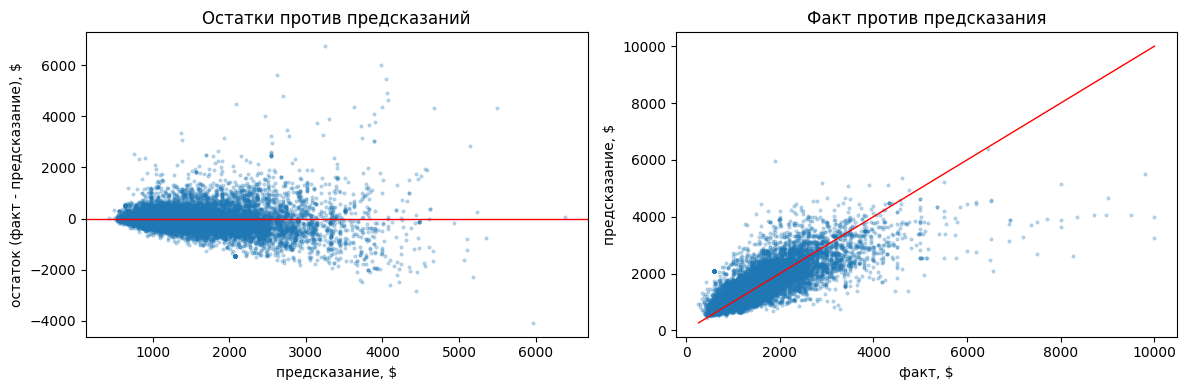

In [7]:
import matplotlib.pyplot as plt

residuals = val[TARGET].to_numpy() - predictions

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(predictions, residuals, s=4, alpha=0.25)
axes[0].axhline(0, color="red", linewidth=1)
axes[0].set_xlabel("предсказание, $")
axes[0].set_ylabel("остаток (факт - предсказание), $")
axes[0].set_title("Остатки против предсказаний")

axes[1].scatter(val[TARGET], predictions, s=4, alpha=0.25)
limits = [val[TARGET].min(), val[TARGET].max()]
axes[1].plot(limits, limits, color="red", linewidth=1)
axes[1].set_xlabel("факт, $")
axes[1].set_ylabel("предсказание, $")
axes[1].set_title("Факт против предсказания")

fig.tight_layout()
fig.savefig("../reports/figures/baseline_residuals.png", bbox_inches="tight")

На графике «факт против предсказания» хорошо видно, что модель сжимает диапазон...
дешёвое жильё переоценивает, дорогое недооценивает. Для KNN это ожидаемо — предсказание
всегда является средним по соседям и не может выйти за пределы наблюдаемых значений.

Разбивка по квантилям подтверждает на верхнем ценовом сегменте MAE в несколько раз выше,
чем на нижнем. Дальше выходит либо обучение на `log(price)`, либо модели,
которые лучше работают с хвостами.

In [8]:
save_run(
    "cp1_baseline_notebook",
    metrics=results,
    params={
        "n_raw_features": len(RAW_NUMERIC),
        "n_fe_features": len(features),
        "n_train": len(train), "n_val": len(val), "n_test": len(test),
    },
    notes="CP1: baseline из ноутбука 03. Тестовая выборка не использовалась.",
)

20:42:41 | INFO    | src.models.evaluate | Сохранил результат прогона: /Users/dianochka_l/Desktop/Project_ML/experiments/runs/cp1_baseline_notebook.json


## 5. Итоги
- данные найдены, описаны, очищены (99 025 строк, 0.47% потерь)
- сгенерировано 60 признаков вместо 5 исходных
- найдены и устранены две утечки таргета, сплит групповой и проверенный
- метрика выбрана и обоснована — MAE в долларах
- baseline построен

**Гипотезы**

| # | Гипотеза | Как проверять |
|---|---|---|
| 1 | Градиентный бустинг (LightGBM / CatBoost) обыграет KNN | сравнение MAE на val |
| 2 | Target encoding города внутри фолдов добавит больше всего | с ним и без него |
| 3 | Обучение на `log(price)` уменьшит ошибку на дорогом сегменте | MAE по квантилям |
| 4 | TF-IDF по очищенному тексту объявления даст прирост | с текстовыми признаками и без |
| 5 | Снижение размерности (PCA/SVD) поможет KNN | MAE KNN на сжатом пространстве |
| 6 | Ансамбль (стекинг бустинга и KNN) даст лучший результат | сравнение с отдельными моделями |

Тестовая выборка до конца не трогается... все сравнения будут на валидации